### Phase 1:________ Cadrage et Acquisition _________________________________________________________________________________



 ### L'objectif :Mon modèle doit prédire la note d’un étudiant en fonction de son profil socio-économique

  ### Type de problème :

     Il s’agit d’un problème de régression, car la sortie est une valeur numérique.

### Présentation du dataset
Le dataset utilisé contient des informations sur les étudiants ainsi que leurs résultats aux examens.  
Chaque ligne représente un étudiant et ses caractéristiques personnelles et académiques.

### Variable cible :
La variable cible (y) est le math score.

### Variables explicatives :
Les variables explicatives (X) utilisées pour la prédiction sont :
- gender  
- race/ethnicity  
- parental level of education  
- lunch  
- test preparation course  
- reading score  
- writing score .

### Problématique :
Ce modèle vise à répondre à la question suivante :
L’origine socio-économique influence-t-elle les résultats scolaires ?


### Phase 2:  Analyse Exploratoire (EDA)

### 1:Compréhension générale du dataset


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plot
import seaborn as sns
##Chargement du dataset
df = pd.read_csv("StudentsPerformance.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [4]:
df.tail()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77
999,female,group D,some college,free/reduced,none,77,86,86


In [5]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


Les résultats montrent que les notes des étudiants sont globalement moyennes.
La moyenne est autour de 66 pour les mathématiques, 69 pour la lecture et 68 pour l’écriture.

On remarque aussi que les valeurs minimales et maximales sont très différentes, ce qui veut dire qu’il y a des étudiants très faibles et d’autres très forts.

La moyenne et la médiane sont proches, donc les données sont assez équilibrées.

Mais il y a quelques valeurs très différentes des autres, ce qui peut montrer la présence de quelques outliers.

Enfin, l’écart-type est environ 15, ce qui signifie que les notes sont un peu dispersées, mais pas trop.

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


 L’analyse du dataset montre qu’il contient 1000 observations et 8 variables. 5 variables sont catégorielles et 3 sont numériques. Aucune valeur manquante n’a été détectée, ce qui indique que les données sont complètes et prêtes pour l’analyse. Les variables numériques représentent les scores des étudiants, tandis que les variables catégorielles décrivent leur profil socio-économique et académique.

### 2:Vérification des données

In [25]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

L’analyse des valeurs manquantes montre qu’il n’y a aucune donnée manquante dans le dataset.

In [15]:
df.duplicated().sum()

np.int64(0)

La vérification des doublons montre qu’il n’existe aucune ligne dupliquée dans le dataset.Cela montre que le dataset est bien organisé et ne contient pas de lignes répétées.

### 3: Distribution (Histogram)

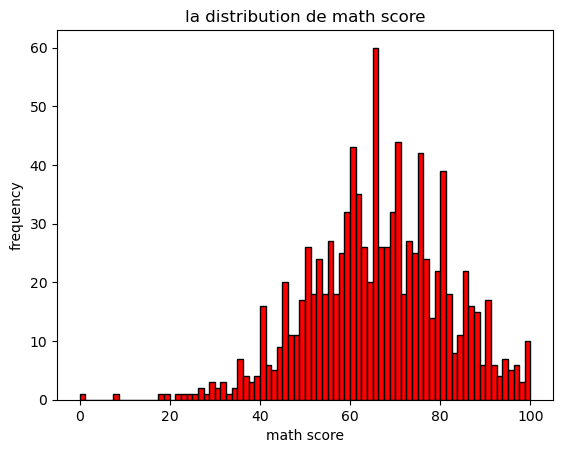

In [9]:
plot.hist(df['math score'] , bins=80 , color='red' ,edgecolor='black')
plot.xlabel("math score")
plot.ylabel("frequency")
plot.title("la distribution de math score")
plot.show()

La plupart des étudiants ont des notes entre 50 et 80 On observe un pic autour de 65, ce qui représente le score le plus fréquent. Le graphique est presque équilibré, mais on remarque une légère asymétrie vers la gauche à cause de quelques faibles notes.

### 4 : Boxplots

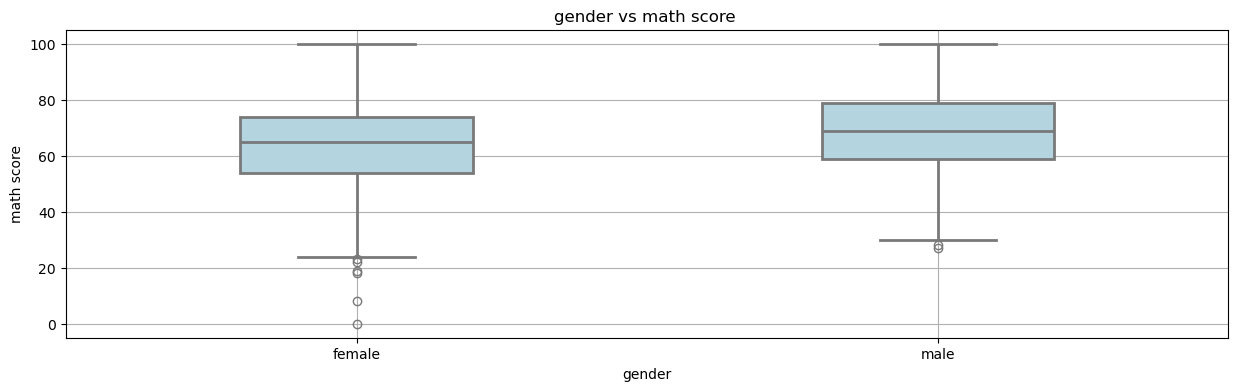

In [10]:
plot.figure(figsize=(15,4))
sns.boxplot( x="gender", y="math score" ,data = df ,color = 'lightblue' ,linewidth=2,width=0.4,orient='v')
plot.title('gender vs math score ')
plot.xlabel('gender')
plot.ylabel('math score')
plot.grid()
plot.show()

Le boxplot montre une légère différence entre les garçons et les filles dans les scores de mathématiques. La médiane des garçons est un peu plus élevée, mais la différence reste faible. On observe également quelques valeurs extrêmes représentant des étudiants avec des notes très faibles.

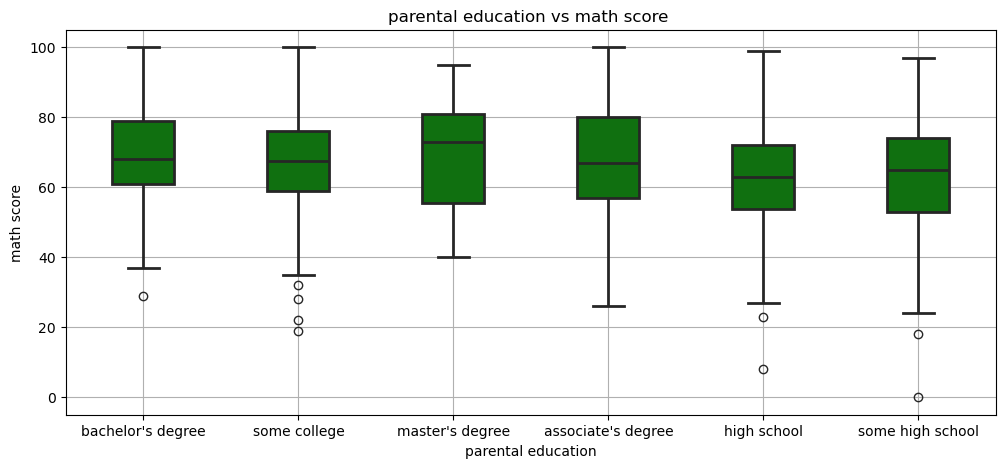

In [11]:
plot.figure(figsize=(12,5))
sns.boxplot( x="parental level of education", y="math score" ,data = df ,color = 'green' ,linewidth=2,width=0.4,orient='v')
plot.title('parental education vs math score ')
plot.xlabel('parental education')
plot.ylabel('math score')
plot.grid()
plot.show()

le boxplot montre une relation entre le niveau d’éducation des parents et les scores en mathématiques. Les élèves dont les parents ont un master obtiennent les meilleures performances (médiane ≈ 72), suivis de ceux avec un bachelor ou un associate’s degree. Les résultats les plus faibles sont observés chez les élèves dont les parents ont un niveau high school ou moins (médiane ≈ 63–64). Cela indique une tendance générale : plus le niveau d’éducation des parents est élevé, meilleurs sont les résultats en mathématiques. Toutefois, il s’agit d’une corrélation et non d’une causalité.

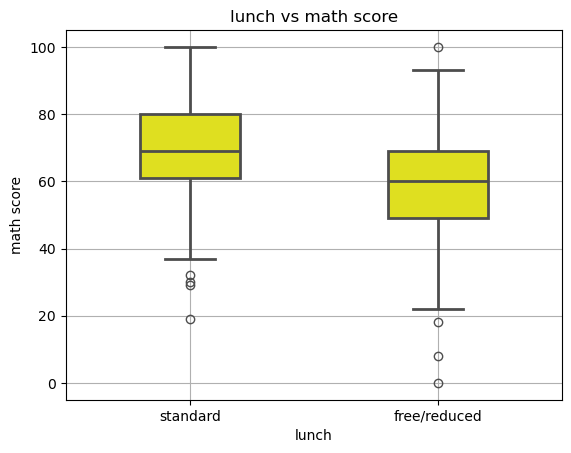

In [12]:

sns.boxplot( x="lunch", y="math score" ,data = df ,color = 'yellow' ,linewidth=2,width=0.4,orient='v')
plot.title('lunch vs math score')
plot.xlabel('lunch')
plot.ylabel('math score')
plot.grid()
plot.show()

Le diagramme en boîte montre l’impact du type de déjeuner sur les scores en mathématiques. Les élèves ayant un déjeuner standard obtiennent de meilleurs résultats, avec une médiane d’environ 70, tandis que ceux ayant un déjeuner gratuit ou réduit présentent des scores plus faibles, avec une médiane proche de 60. On observe également une légère différence dans la dispersion des notes. Cela suggère que le type de repas peut être associé à la performance scolaire, probablement en lien avec le contexte socio-économique des élèves.

### 5 : Correlation

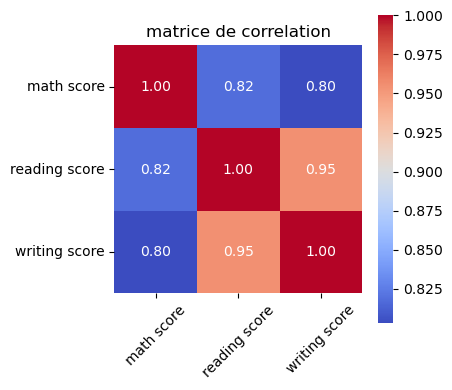

In [23]:
correlation_matrix=df.corr(numeric_only=True)
plot.figure(figsize=(4,4))
sns.heatmap(correlation_matrix, annot=True , fmt=".2f" ,cmap="coolwarm",cbar=True,square=True)
plot.title("matrice de correlation")
plot.xticks(rotation=45)
plot.yticks(rotation=0)
plot.show()

### Phase 3 : Préparation des Données 